# 0 · A day in the life of BTCUSDT

**The question:** what does high-frequency data actually look like, before we compute anything clever?

We use one full day (27 March 2024, UTC) of Binance USDⓈ-M perpetual futures on BTCUSDT:
the most traded crypto contract in the world. Two files:

| file | one row = | what's in it |
|---|---|---|
| `bookTicker` | any change at the **best bid or best ask** (price or size) | bid, bid size, ask, ask size, timestamp |
| `trades` | one **fill** between a buyer and a seller | price, size, timestamp, *which side was the aggressor* |

That last column is a gift. On stock exchanges the public tape usually doesn't say who crossed the
spread, so researchers have to guess (chapter 2 measures how well the guesses work).

**Vocabulary used everywhere in this project**

- **Bid / ask**: highest price someone is waiting to buy at / lowest price someone is waiting to sell at.
- **Mid** = (bid + ask) / 2. **Spread** = ask − bid.
- **Tick** = the minimum price increment. For BTCUSDT futures it's 0.1 USDT.
- **Maker** = the resting order (provides liquidity). **Taker / aggressor** = the order that crosses the
  spread and trades immediately (takes liquidity).
- **Sign** of a trade: +1 if the aggressor was a buyer, −1 if a seller.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from micro.data import load_quotes, load_trades, aggregate_trades, TICK
from micro.book import mid, spread_ticks, to_ms
from micro.plotting import style, save, BLUE, ORANGE, GREY

style()
quotes = load_quotes()   # first run converts the CSV to parquet (~30 s); later runs take a few seconds
trades = load_trades()
quotes.head()

,ts,bid,bid_qty,ask,ask_qty
0,2024-03-27 00:00:00.006000+00:00,70044.1,4.500,70044.2,0.912
1,2024-03-27 00:00:00.009000+00:00,70044.1,5.486,70044.2,0.912
2,2024-03-27 00:00:00.012000+00:00,70044.1,5.486,70044.2,0.798
3,2024-03-27 00:00:00.012000+00:00,70044.1,7.521,70044.2,0.798
4,2024-03-27 00:00:00.020000+00:00,70044.1,7.521,70044.2,0.800


In [2]:
trades.head()

,ts,price,qty,sign,id
0,2024-03-27 00:00:00.047000+00:00,70044.2,0.046,1,4804181758
1,2024-03-27 00:00:00.047000+00:00,70044.2,0.010,1,4804181759
2,2024-03-27 00:00:00.047000+00:00,70044.2,0.071,1,4804181760
3,2024-03-27 00:00:00.047000+00:00,70044.2,0.023,1,4804181761
4,2024-03-27 00:00:00.048000+00:00,70044.2,0.048,1,4804181762


## How much data is a "day"?

In [3]:
orders = aggregate_trades(trades)
day_seconds = 24 * 3600
print(f"best bid/ask updates : {len(quotes):>12,}   ({len(quotes) / day_seconds:6.1f} per second)")
print(f"fills                : {len(trades):>12,}   ({len(trades) / day_seconds:6.1f} per second)")
print(f"aggressive orders    : {len(orders):>12,}   ({len(orders) / day_seconds:6.1f} per second)")
print(f"BTC traded           : {trades.qty.sum():>12,.0f}   (~${(trades.qty * trades.price).sum() / 1e9:.1f} billion)")
print(f"fills per order      : mean {orders.n_fills.mean():.2f}, median {orders.n_fills.median():.0f}, max {orders.n_fills.max()}")

best bid/ask updates :   15,814,430   ( 183.0 per second)
fills                :    5,478,411   (  63.4 per second)
aggressive orders    :    1,447,469   (  16.8 per second)
BTC traded           :      407,758   (~$28.5 billion)
fills per order      : mean 3.78, median 1, max 385


Three things to notice:

1. The book changes ~180 times a second, about 3x as often as trades happen. **Most of the action in a
   market is quotes being placed and cancelled, not trades.** That's why the order book (chapters 5 and 6)
   contains so much information.
2. One aggressive order often fills against several resting orders: one row in our `orders` table but
   several in `trades`. When we ask questions about *decisions* (who decided to buy?), we use `orders`.
   `aggregate_trades` merges fills with the same millisecond and side.
3. Almost $30 billion notional in one day, on one contract. This is a deep, fast market.

## The price path

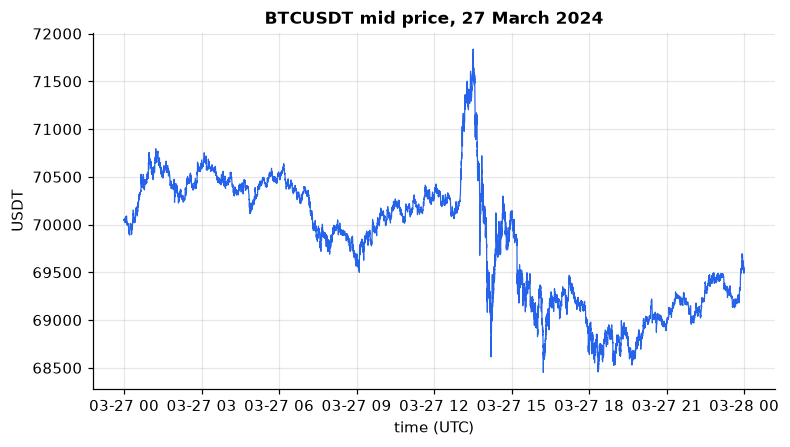

In [4]:
m = mid(quotes)
step = 1000  # plotting 16 million points is slow and pointless: thin it out
fig, ax = plt.subplots()
ax.plot(quotes.ts.iloc[::step], m[::step], color=BLUE, lw=0.8)
ax.set(title="BTCUSDT mid price, 27 March 2024", ylabel="USDT", xlabel="time (UTC)")
save(fig, "00_price_path")

## When does trading happen?

Crypto trades 24/7, so you might expect flat activity. It isn't.

13:00-15:00 UTC share of daily volume: 41%


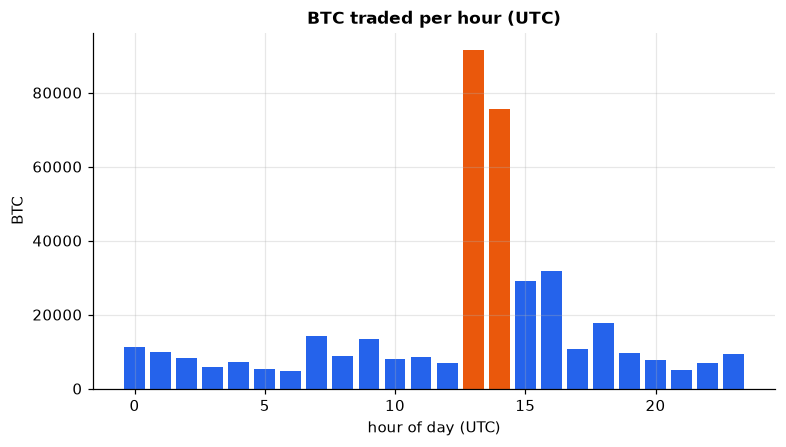

In [5]:
by_hour = trades.groupby(trades.ts.dt.hour).qty.sum()
fig, ax = plt.subplots()
ax.bar(by_hour.index, by_hour.values, color=[ORANGE if h in (13, 14) else BLUE for h in by_hour.index])
ax.set(title="BTC traded per hour (UTC)", xlabel="hour of day (UTC)", ylabel="BTC")
save(fig, "00_volume_by_hour")
print(f"13:00-15:00 UTC share of daily volume: {by_hour.loc[[13, 14]].sum() / by_hour.sum():.0%}")

The two orange hours are 13:00–15:00 UTC, which contain the **US equity market open** (9:30 New York =
13:30 UTC in late March). Crypto is not traded in a vacuum: US institutions and ETF flows (spot
bitcoin ETFs launched in January 2024) concentrate activity when Wall Street opens. Those two hours alone
carry about 40% of the day's volume.

Intraday seasonality like this matters for every statistic we compute: volatility, spreads and trade
rates all change through the day. Pooling a quiet 4 a.m. with a frantic 2 p.m. can mislead (chapter 8
makes this concrete).

## What sizes do people trade?

count    1447469.000
mean           0.282
std            1.746
min            0.001
50%            0.023
90%            0.482
99%            4.117
99.9%         25.232
max          242.605
Name: qty, dtype: float64


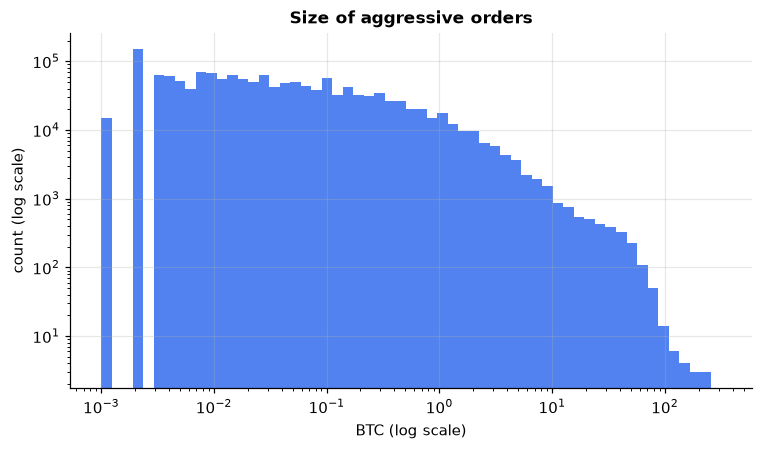

In [6]:
fig, ax = plt.subplots()
bins = np.logspace(-3, 2.5, 60)
ax.hist(orders.qty, bins=bins, color=BLUE, alpha=0.8)
ax.set(xscale="log", yscale="log", title="Size of aggressive orders", xlabel="BTC (log scale)", ylabel="count (log scale)")
save(fig, "00_order_sizes")
print(orders.qty.describe(percentiles=[0.5, 0.9, 0.99, 0.999]).round(3))

Order sizes span **five orders of magnitude** (0.001 BTC ≈ $70 to over 100 BTC ≈ $7 million). The median
order is tiny but the tail is very heavy: the largest 1% of orders carry a big chunk of the volume. A
"typical" trade doesn't exist, which is why chapter 7 studies impact as a function of size instead of
averaging over all trades.

## Data-quality checks (always do these)

In [7]:
st = spread_ticks(quotes, TICK)
qts = to_ms(quotes.ts)
print("crossed or locked books (ask <= bid):", int((st <= 0).sum()))
print("timestamps out of order:", int((np.diff(qts.astype("int64")) < 0).sum()))
print("largest gap between quote updates:", pd.Timedelta(np.diff(qts).max()))

from micro.book import resample_last


def outside_quotes(ts, price):
    """Share of prints strictly outside the bid/ask in force 1 ms before them."""
    bid_b = resample_last(qts, quotes.bid.to_numpy(), ts - np.timedelta64(1, "ms"))
    ask_b = resample_last(qts, quotes.ask.to_numpy(), ts - np.timedelta64(1, "ms"))
    return np.mean((price > ask_b + 1e-9) | (price < bid_b - 1e-9))


print(f"fills printing outside the previous bid/ask:            {outside_quotes(to_ms(trades.ts), trades.price.to_numpy()):.1%}")
print(f"orders whose FIRST fill is outside the previous bid/ask: {outside_quotes(to_ms(orders.ts), orders.first_price.to_numpy()):.1%}")
print(f"orders that sweep more than one price level:            {(orders.first_price != orders.last_price).mean():.1%}")

crossed or locked books (ask <= bid): 0
timestamps out of order: 0
largest gap between quote updates: 0 days 00:00:02.255000


fills printing outside the previous bid/ask:            45.7%
orders whose FIRST fill is outside the previous bid/ask: 2.8%


orders that sweep more than one price level:            16.1%


No crossed books and no time-travel. The "outside the quotes" numbers look alarming until you separate fills from orders:

- Almost half of all **fills** print outside the previous best bid/ask. That's because big orders **sweep** several
  price levels, and each level is several fills. A sweep of 385 fills contributes 385 rows.
- Only a few percent of **orders** have their *first* fill outside the quotes. Those are cases where the book
  changed within the same millisecond, so our "previous quote" is stale. Millisecond timestamps are coarse
  when 180 things happen per second.

Lesson: the same data can tell opposite stories depending on what you count. Keep this in mind in chapters 2 and 4.

---
### Interview angle

<details><summary><b>"How would you sanity-check a new tick dataset?"</b></summary>

Crossed/locked books, out-of-order or duplicated timestamps, gaps (exchange outages, recorder
disconnects), trades outside the quotes, prices that jump 10% and come back (bad prints), and whether
timestamps are exchange time or receive time. Then check volume and price against a second source.
</details>

<details><summary><b>"Why might you aggregate fills into orders?"</b></summary>

One taker order sweeping 10 resting orders is one decision. Counting it as 10 trades inflates trade
counts, makes signs look far more autocorrelated (try `acf(trades.sign)` vs `acf(orders.sign)` in
chapter 2) and breaks models that assume one event = one decision (e.g. Hawkes, chapter 8).
</details>

### Try this yourself
1. Plot the number of quote updates per minute. Does it track volume?
2. Download a different day (`scripts/download_binance.py --date 2024-03-23`, a Saturday). Is the US-open bump still there?